In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('posts_12months.csv')
df

,PostId,PostUrl,PostEngagement,Platform,ChannelID,ChannelName,ChannelUid,ChannelUrl,ChannelEngagement,post_body_text,...,post_media_urls,LikesCount,SharesCount,CommentsCount,ViewsCount,post_media_file,embedded_post_text,original_image_url,original_media_url,search_data
0,747867491,https://www.youtube.com/shorts/kavNCxURilo,NaN,YouTube,6054830,Senator Elizabeth Warren,blank_for_now,blank_for_now,"{""follower_count"":216000,""following_count"":0,""...",Silence is complicity.\n \nWe all need to spea...,...,https://www.junkipedia.org/rails/active_storag...,27.0,0.0,0,107,NaN,NaN,not_needed,NaN,NaN
1,747851191,https://twitter.com/PJQualityGuru/status/20194...,NaN,Twitter,10600801,Perry Johnson,blank_for_now,blank_for_now,"{""follower_count"":15967,""following_count"":1248...",We aren’t backing down. Turn the channel on B...,...,https://www.junkipedia.org/rails/active_storag...,5.0,0.0,0,148,NaN,NaN,not_needed,not_needed,NaN
2,747886094,https://www.facebook.com/reel/1424042995797310/,NaN,Facebook,6914292,Alex Padilla,blank_for_now,blank_for_now,"{""follower_count"":34000,""following_count"":0,""l...","After Renee Good was killed, Trump officials a...",...,https://www.junkipedia.org/rails/active_storag...,327.0,47.0,173,2118,https://www.junkipedia.org/rails/active_storag...,NaN,not_needed,not_needed,NaN
3,747869219,https://twitter.com/repmorgan/status/201941867...,NaN,Twitter,7207463,Patricia Morgan,blank_for_now,blank_for_now,"{""follower_count"":8034,""following_count"":592,""...",RT @EricLDaugh: 🚨 HOLY SMOKES. Tom Homan just ...,...,NaN,0.0,17200.0,0,0,NaN,🚨 HOLY SMOKES. Tom Homan just ERUPTED in respo...,not_needed,not_needed,NaN
4,747843891,https://twitter.com/RepMenendez/status/2019416...,NaN,Twitter,16598549,Rep. Rob Menendez,blank_for_now,blank_for_now,"{""follower_count"":7739,""following_count"":375,""...",Community is how we keep our communities safe....,...,https://www.junkipedia.org/rails/active_storag...,6.0,4.0,7,150,NaN,NaN,not_needed,https://video.twimg.com/amplify_video/20194161...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39802,430726543,https://twitter.com/melton4iowa/status/1887203...,NaN,Twitter,8238685,Ryan Melton,blank_for_now,blank_for_now,"{""follower_count"":5003,""following_count"":4832,...",Great turnout in the middle of a midweek ice s...,...,NaN,27.0,6.0,6,897,NaN,NaN,"[""https://pbs.twimg.com/media/GjCxUjDXsAAx_yM....",not_needed,NaN
39803,430739175,https://www.facebook.com/meltonforiowa/posts/p...,NaN,Facebook,8402430,"Ryan Melton: Dem Candidate for U.S. House, IA-04",blank_for_now,blank_for_now,"{""follower_count"":1139,""following_count"":0,""li...",Great turnout in the middle of a midweek ice s...,...,https://www.junkipedia.org/rails/active_storag...,104.0,4.0,11,0,NaN,NaN,not_needed,not_needed,NaN
39804,430745952,https://www.facebook.com/RepBrittanyPettersen/...,NaN,Facebook,19520356,U.S. Rep Brittany Pettersen,blank_for_now,blank_for_now,"{""follower_count"":1689,""following_count"":0,""li...",As Trump's mass deportations continue across t...,...,https://www.junkipedia.org/rails/active_storag...,66.0,9.0,39,0,NaN,NaN,not_needed,not_needed,NaN
39805,430793362,https://twitter.com/RepPettersen/status/188720...,NaN,Twitter,15681665,U.S. Rep. Brittany Pettersen,blank_for_now,blank_for_now,"{""follower_count"":7746,""following_count"":369,""...",As Trump's mass deportations continue across t...,...,NaN,6.0,1.0,12,1236,NaN,NaN,https://pbs.twimg.com/card_img/188793735843296...,not_needed,NaN


In [ ]:
import syllables #package to estimate syllables in a wordl not perfect
df2 = df[['PostId', 'post_body_text', 'Platform']].copy()
df3 = df2.sample(5000, random_state = 123).reset_index(drop=True)
df3['read_ease'] = None #readability test 1
df3['gunning_fog'] = None #readability test 2
for i in range(0, len(df3)): #basic filtering to break up posts; this will be done later via an LLM
    if(type(df3['post_body_text'][i]) == str):
        x = df3['post_body_text'][i].split()
        sl = len(x)/(df3['post_body_text'][i].count('. ') + df3['post_body_text'][i].count('? ') + df3['post_body_text'][i].count('! ') + df3['post_body_text'][i].count('.\n') +df3['post_body_text'][i].count('?\n') +df3['post_body_text'][i].count('!\n') + 1) #need to account for more endings
        nosw = 0
        complex = 0
        for j in range(0, len(x)):
            if(syllables.estimate(x[j]) == 1):
                nosw += 1
            if(syllables.estimate(x[j]) >= 3):
                complex += 1
        df3.loc[i, 'gunning_fog'] = 0.4*(sl + 100*(complex/len(x)))
        nosw = nosw * (100/len(x))
        df3.loc[i, 'read_ease'] = 1.599*nosw - 1.015*sl - 31.517
df3['read_ease'] = df3['read_ease'].fillna(-1)
finalread = [score for score in df3['read_ease'] if score > 0]

C:\Users\elija\AppData\Local\Temp\ipykernel_26160\429516269.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['read_ease'] = df3['read_ease'].fillna(-1)


In [ ]:
 df3

,PostId,post_body_text,Platform,read_ease,gunning_fog
0,737897538,Minnesota is suing to stop ICE from doing its ...,Facebook,73.260000,8.158049
1,534628216,January 6 was a violent insurrection that resu...,Twitter,41.628909,16.036364
2,736841313,This is abhorrent. The 4th amendment is the la...,Twitter,68.023147,8.105882
3,553116561,ICE is turning courthouses into traps.,Facebook,15.693000,9.066667
4,648338696,I want answers and a full investigation into t...,InstagramDirect,23.336000,20.0
...,...,...,...,...,...
4995,526798252,Thank God for our ICE agents!! \n\nThese visco...,Twitter,56.091810,8.019048
4996,691959550,TRUMP is doing it! The Golden Age of America i...,Facebook,49.005500,10.733333
4997,631615421,RT @VigilantFox: Chuck Schumer is already usin...,Twitter,42.915500,11.466667
4998,542444757,"My team, along with the House Judiciary and Ho...",Facebook,30.467750,21.366667


Text(0.5, 1.0, 'Flesch Reading Ease Scores of ICE Posts (5000 Sample)')

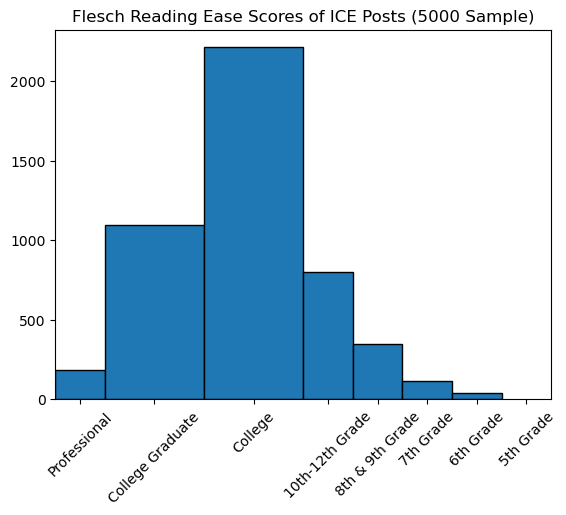

In [4]:
plt.hist(finalread, bins=[0, 10, 30, 50, 60, 70, 80, 90], edgecolor='black')
plt.xticks(labels=['Professional', 'College Graduate', 'College', '10th-12th Grade', '8th & 9th Grade', '7th Grade', '6th Grade', '5th Grade'], ticks=[5, 20, 40, 55, 65, 75, 85, 95])
plt.xticks(rotation=45)
plt.xlim(0, 100)
plt.title('Flesch Reading Ease Scores of ICE Posts (5000 Sample)')

C:\Users\elija\AppData\Local\Temp\ipykernel_26160\3919752323.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['gunning_fog'] = df3['gunning_fog'].fillna(0)


Text(0.5, 1.0, 'Gunning Fog of ICE Posts (5000 Sample)')

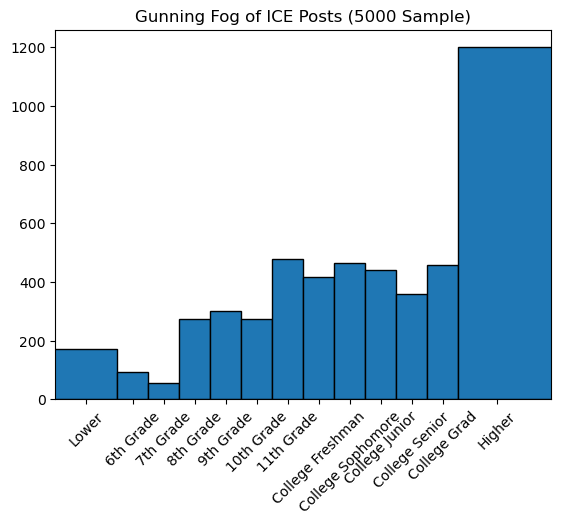

In [5]:
df3['gunning_fog'] = df3['gunning_fog'].fillna(0)
plt.hist(df3['gunning_fog'].dropna(), bins=[min(df3['gunning_fog']),6,7,8,9,10,11,12, 13, 14, 15, 16, 17, max(df3['gunning_fog'])], edgecolor='black')
plt.xticks(labels=['Lower','6th Grade', '7th Grade', '8th Grade', '9th Grade', '10th Grade', '11th Grade', 'College Freshman', 'College Sophomore', 'College Junior', 'College Senior', 'College Grad', 'Higher'], ticks=[5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 18.25])
plt.xticks(rotation=45)
plt.xlim(4, 20)
plt.title('Gunning Fog of ICE Posts (5000 Sample)')

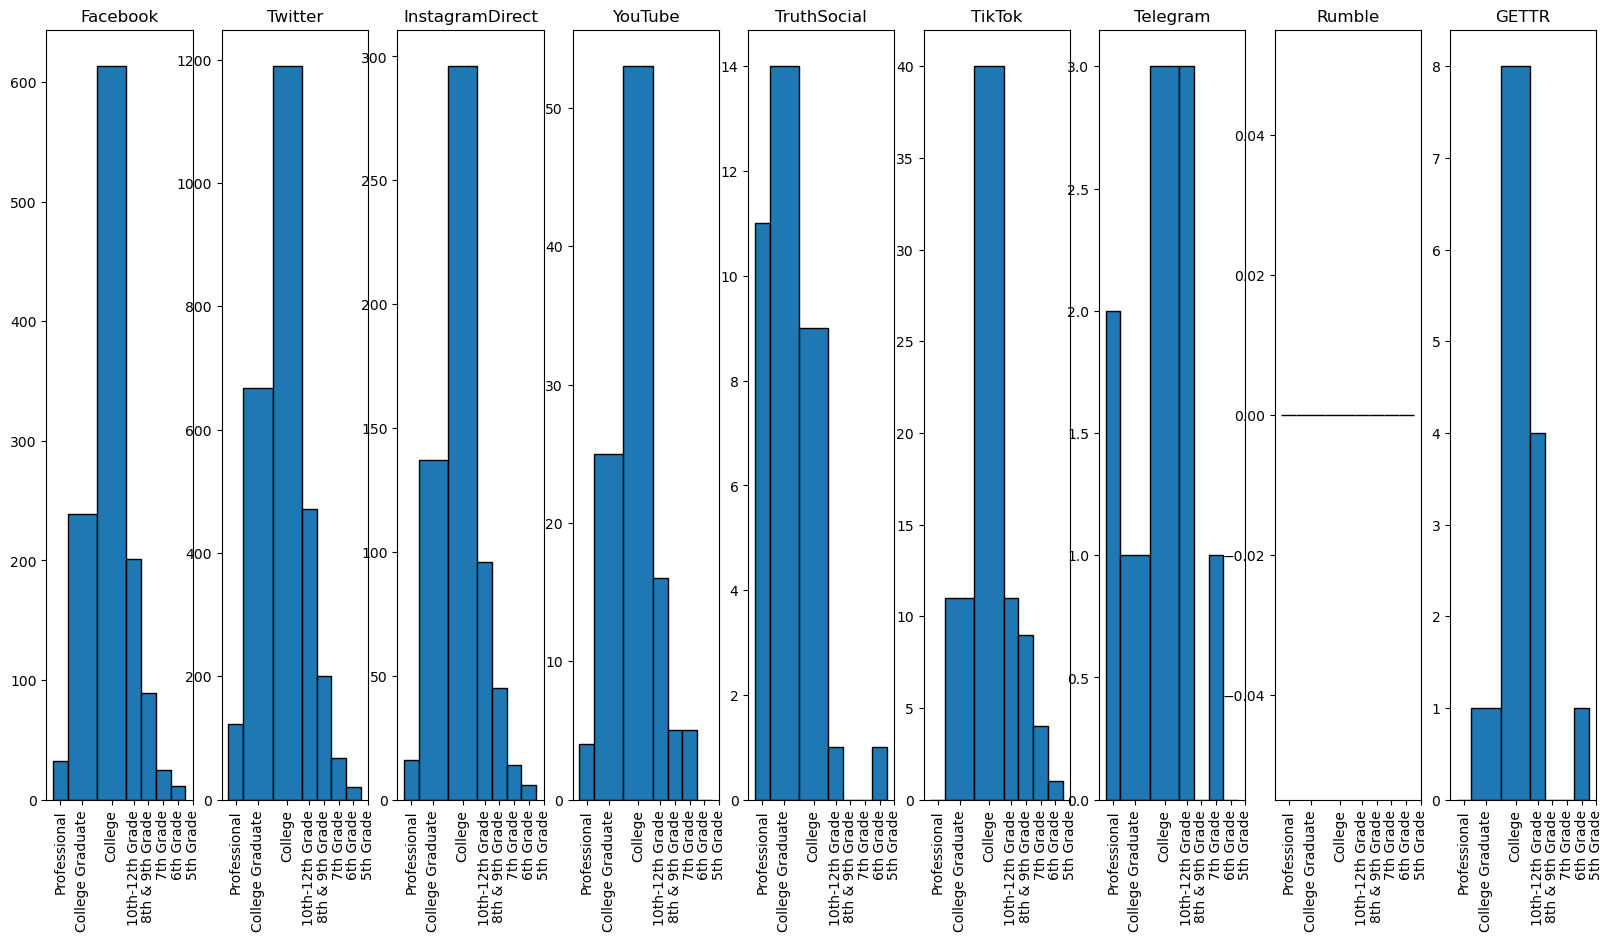

In [6]:
fig, axs = plt.subplots(1, len(df3['Platform'].unique()), figsize=(20, 10))
j = 0
for platform in df3['Platform'].unique():
   axs[j].hist(df3[df3['Platform'] == platform]['read_ease'].dropna(), bins=[0, 10, 30, 50, 60, 70, 80, 90], edgecolor='black')
   axs[j].set_title(platform)
   axs[j].set_xticks(ticks=[5, 20, 40, 55, 65, 75, 85, 95], labels=['Professional', 'College Graduate', 'College', '10th-12th Grade', '8th & 9th Grade', '7th Grade', '6th Grade', '5th Grade'], rotation=90)
   j += 1

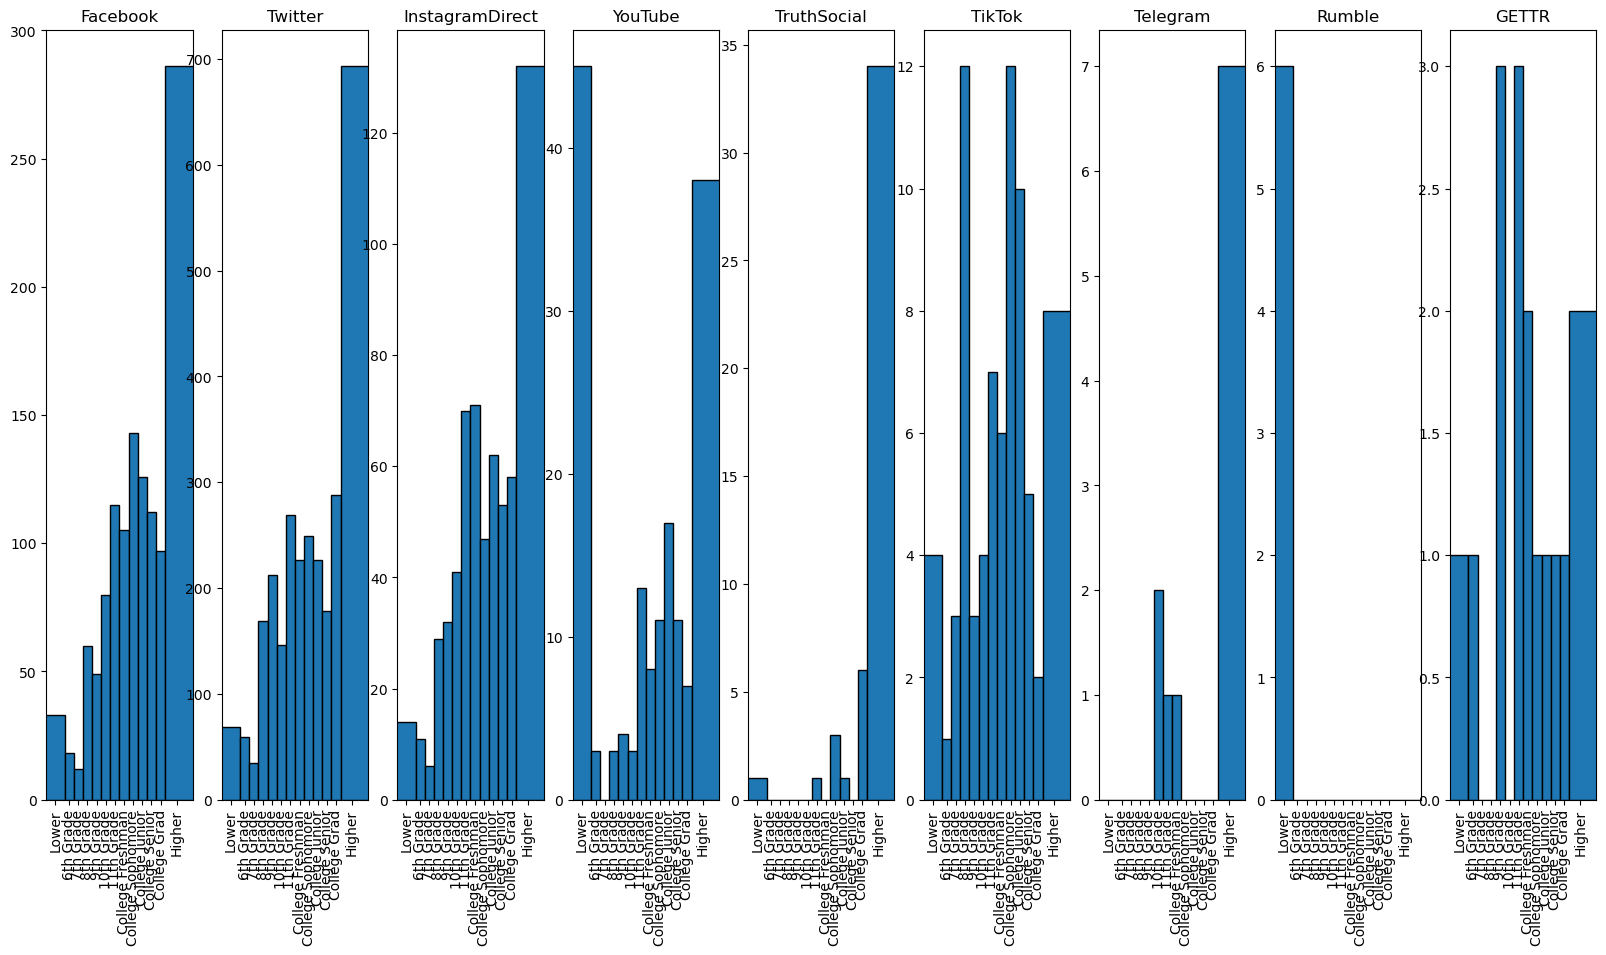

In [7]:
fig, axs = plt.subplots(1, len(df3['Platform'].unique()), figsize=(20, 10))
j = 0
for platform in df3['Platform'].unique():
   axs[j].hist(df3[df3['Platform'] == platform]['gunning_fog'].dropna(), bins=[min(df3['gunning_fog']),6,7,8,9,10,11,12, 13, 14, 15, 16, 17, max(df3['gunning_fog'])], edgecolor='black')
   axs[j].set_title(platform)
   axs[j].set_xticks(labels=['Lower','6th Grade', '7th Grade', '8th Grade', '9th Grade', '10th Grade', '11th Grade', 'College Freshman', 'College Sophomore', 'College Junior', 'College Senior', 'College Grad', 'Higher'], ticks=[5, 6.5, 7.5, 8.5, 9.5, 10.5, 11.5, 12.5, 13.5, 14.5, 15.5, 16.5, 18.25], rotation = 90)
   axs[j].set_xlim(4, 20)
   j += 1

In [9]:
dfts = df.copy()
dfts["published_at"] = pd.to_datetime(dfts["published_at"], errors="coerce", utc=True)
dfts = dfts.dropna(subset=["published_at"])

In [12]:
weekly = (
    dfts.set_index("published_at")
      .sort_index()
      .resample("W-MON")
      .size()
      .rename("ice_posts")
      .reset_index()
)
events = [
    ("2025-01-20", "Inauguration + immigration EOs"),
    ("2025-01-23", "ICE raids begin (sanctuary cities)"),
    ("2025-01-29", "Laken Riley Act"),
    ("2025-02-01", "Grammys (celebs speak out)"),
    ("2025-06-19", "Alligator Alcatraz revealed (FL AG)"),
    ("2025-07-01", "Alligator Alcatraz opens"),
    ("2025-07-04", "One Big Beautiful Act passed"),
    ("2025-12-01", "Operation Metro Surge starts (approx)"),
    ("2026-01-07", "Renee Good (note)"),
    ("2026-01-23", "General Strike (Minneapolis)"),
    ("2026-01-24", "Alex Pretti (note)"),
]

events_df = pd.DataFrame(events, columns=["date", "label"])
events_df["date"] = pd.to_datetime(events_df["date"], utc=True)


In [39]:
dfts[(dfts["published_at"] > weekly['published_at'].iloc[1]) & (dfts["published_at"] < weekly['published_at'].iloc[2])]

,PostId,PostUrl,PostEngagement,Platform,ChannelID,ChannelName,ChannelUid,ChannelUrl,ChannelEngagement,post_body_text,...,post_media_urls,LikesCount,SharesCount,CommentsCount,ViewsCount,post_media_file,embedded_post_text,original_image_url,original_media_url,search_data
39094,478740108,https://twitter.com/CVGforTX/status/1893787697...,NaN,Twitter,23235397,Christian V. Garcia,blank_for_now,blank_for_now,"{""follower_count"":197,""following_count"":349,""l...",RT @LeadingReport: BREAKING: Trump administrat...,...,NaN,0.0,2029.0,0,0,NaN,BREAKING: Trump administration is directing IC...,not_needed,not_needed,NaN
39095,445205020,https://twitter.com/DerrickEvans4WV/status/189...,NaN,Twitter,20828070,Derrick Evans,blank_for_now,blank_for_now,"{""follower_count"":816827,""following_count"":170...",🚨BREAKING: Trump administration just ordered ...,...,NaN,1144.0,170.0,26,21541,NaN,NaN,not_needed,not_needed,NaN
39096,445170748,https://www.facebook.com/groups/farmer4us/post...,NaN,Facebook,22842324,Keith Mundy for Congress,blank_for_now,blank_for_now,"{""follower_count"":1600,""following_count"":null,...",Trump's policies have significantly impacted f...,...,https://www.junkipedia.org/rails/active_storag...,0.0,35.0,0,0,NaN,NaN,not_needed,not_needed,NaN
39097,445156067,https://twitter.com/MaxwellFrostFL/status/1893...,NaN,Twitter,6605962,Maxwell Alejandro Frost,blank_for_now,blank_for_now,"{""follower_count"":270874,""following_count"":295...",RT @TheGoodLiars: Talked to someone wearing an...,...,NaN,0.0,5221.0,0,0,NaN,Talked to someone wearing an ICE costume at CP...,not_needed,https://video.twimg.com/amplify_video/18937036...,NaN
39098,445144117,https://twitter.com/CargileForCA35/status/1893...,NaN,Twitter,7860234,Mike Cargile,blank_for_now,blank_for_now,"{""follower_count"":6747,""following_count"":3098,...",RT @RealAlexJones: Must Watch Video: Tom Homan...,...,NaN,0.0,3276.0,0,0,NaN,Must Watch Video: Tom Homan Drops A Nuclear Bo...,not_needed,not_needed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39287,439425754,https://twitter.com/KatyLStamper/status/189152...,NaN,Twitter,25501863,Katy L. Stamper,blank_for_now,blank_for_now,"{""follower_count"":935,""following_count"":1106,""...",RT @nataliegwinters: Mark Zuckerberg is fundin...,...,NaN,0.0,1972.0,0,0,NaN,Mark Zuckerberg is funding groups tipping off ...,not_needed,not_needed,NaN
39288,444598173,https://twitter.com/RepNicole/status/189152045...,NaN,Twitter,8644040,Office of Rep. Nicole Malliotakis,blank_for_now,blank_for_now,"{""follower_count"":34118,""following_count"":448,...",https://t.co/Rs4ZI9qmob,...,NaN,13.0,4.0,12,2137,NaN,NaN,https://pbs.twimg.com/card_img/189340904985448...,not_needed,NaN
39289,439401189,https://www.facebook.com/RepNicole/posts/pfbid...,NaN,Facebook,4864981,U.S. Rep. Nicole Malliotakis,blank_for_now,blank_for_now,"{""follower_count"":15000,""following_count"":0,""l...",https://www.foxnews.com/video/6368891154112,...,https://www.junkipedia.org/rails/active_storag...,48.0,2.0,39,0,NaN,NaN,not_needed,not_needed,NaN
39290,478742772,https://twitter.com/CVGforTX/status/1891390677...,NaN,Twitter,23235397,Christian V. Garcia,blank_for_now,blank_for_now,"{""follower_count"":197,""following_count"":349,""l...",RT @RepMarkGreen: The New York DMV gave driver...,...,NaN,0.0,22203.0,0,0,NaN,The New York DMV gave driver's licenses to ill...,https://pbs.twimg.com/card_img/190610165672884...,not_needed,NaN


In [ ]:
dfts[dfts["published_at"] <= weekly['published_at'].iloc[0]]

,PostId,PostUrl,PostEngagement,Platform,ChannelID,ChannelName,ChannelUid,ChannelUrl,ChannelEngagement,post_body_text,...,post_media_urls,LikesCount,SharesCount,CommentsCount,ViewsCount,post_media_file,embedded_post_text,original_image_url,original_media_url,search_data
39573,433901936,https://twitter.com/Grace4NY/status/1888707700...,NaN,Twitter,10609411,Grace Meng,blank_for_now,blank_for_now,"{""follower_count"":48546,""following_count"":4196...","A science teacher, community member, and DACA ...",...,NaN,12.0,5.0,14,1834,NaN,NaN,https://pbs.twimg.com/card_img/188790502799535...,not_needed,NaN
39574,433782523,https://twitter.com/BeebeForOregon/status/1888...,NaN,Twitter,14118506,Jason Beebe For Oregon™️,blank_for_now,blank_for_now,"{""follower_count"":9300,""following_count"":9444,...",RT @libsoftiktok: ICE arrested 11k illegals in...,...,NaN,0.0,8011.0,0,0,NaN,ICE arrested 11k illegals in just 18 days! htt...,"[""https://pbs.twimg.com/media/GjTb7TUWIAA6eS_....",not_needed,NaN
39575,433756679,https://twitter.com/GhannonBurton/status/18886...,NaN,Twitter,21055089,Col Ghannon Burton (USMC Ret),blank_for_now,blank_for_now,"{""follower_count"":7083,""following_count"":3787,...",Where is the outrage from our US Senators... ...,...,NaN,28.0,7.0,3,518,NaN,NaN,not_needed,not_needed,NaN
39576,433870049,https://www.facebook.com/repmenendez/posts/pfb...,NaN,Facebook,19520346,Rep. Rob Menendez,blank_for_now,blank_for_now,"{""follower_count"":1218,""following_count"":0,""li...",Our office has heard from so many of you who a...,...,https://www.junkipedia.org/rails/active_storag...,22.0,3.0,7,0,NaN,NaN,not_needed,not_needed,NaN
39577,433862312,https://twitter.com/DerrickEvans4WV/status/188...,NaN,Twitter,20828070,Derrick Evans,blank_for_now,blank_for_now,"{""follower_count"":812083,""following_count"":167...",Anyone caught sharing or leaking ICE deportati...,...,NaN,5014.0,649.0,88,47022,NaN,NaN,not_needed,not_needed,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39802,430726543,https://twitter.com/melton4iowa/status/1887203...,NaN,Twitter,8238685,Ryan Melton,blank_for_now,blank_for_now,"{""follower_count"":5003,""following_count"":4832,...",Great turnout in the middle of a midweek ice s...,...,NaN,27.0,6.0,6,897,NaN,NaN,"[""https://pbs.twimg.com/media/GjCxUjDXsAAx_yM....",not_needed,NaN
39803,430739175,https://www.facebook.com/meltonforiowa/posts/p...,NaN,Facebook,8402430,"Ryan Melton: Dem Candidate for U.S. House, IA-04",blank_for_now,blank_for_now,"{""follower_count"":1139,""following_count"":0,""li...",Great turnout in the middle of a midweek ice s...,...,https://www.junkipedia.org/rails/active_storag...,104.0,4.0,11,0,NaN,NaN,not_needed,not_needed,NaN
39804,430745952,https://www.facebook.com/RepBrittanyPettersen/...,NaN,Facebook,19520356,U.S. Rep Brittany Pettersen,blank_for_now,blank_for_now,"{""follower_count"":1689,""following_count"":0,""li...",As Trump's mass deportations continue across t...,...,https://www.junkipedia.org/rails/active_storag...,66.0,9.0,39,0,NaN,NaN,not_needed,not_needed,NaN
39805,430793362,https://twitter.com/RepPettersen/status/188720...,NaN,Twitter,15681665,U.S. Rep. Brittany Pettersen,blank_for_now,blank_for_now,"{""follower_count"":7746,""following_count"":369,""...",As Trump's mass deportations continue across t...,...,NaN,6.0,1.0,12,1236,NaN,NaN,https://pbs.twimg.com/card_img/188793735843296...,not_needed,NaN


In [ ]:
min(dfts["published_at"]), max(dfts["published_at"])

(Timestamp('2025-02-05 16:56:33+0000', tz='UTC'),
 Timestamp('2026-02-05 15:46:31+0000', tz='UTC'))

In [41]:
weekly

,published_at,ice_posts
0,2025-02-10 00:00:00+00:00,264
1,2025-02-17 00:00:00+00:00,272
2,2025-02-24 00:00:00+00:00,211
3,2025-03-03 00:00:00+00:00,195
4,2025-03-10 00:00:00+00:00,348
5,2025-03-17 00:00:00+00:00,236
6,2025-03-24 00:00:00+00:00,209
7,2025-03-31 00:00:00+00:00,183
8,2025-04-07 00:00:00+00:00,162
9,2025-04-14 00:00:00+00:00,191


In [44]:
df4 = df2.copy()
df4['read_ease'] = None
df4['gunning_fog'] = None
for i in range(0, len(df4)):
    if(type(df4['post_body_text'][i]) == str):
        x = df4['post_body_text'][i].split()
        sl = len(x)/(df4['post_body_text'][i].count('. ') + df4['post_body_text'][i].count('? ') + df4['post_body_text'][i].count('! ') + df4['post_body_text'][i].count('.\n') +df4['post_body_text'][i].count('?\n') +df4['post_body_text'][i].count('!\n') + 1) #need to account for more endings
        nosw = 0
        complex = 0
        for j in range(0, len(x)):
            if(syllables.estimate(x[j]) == 1):
                nosw += 1
            if(syllables.estimate(x[j]) >= 3):
                complex += 1
        df4.loc[i, 'gunning_fog'] = 0.4*(sl + 100*(complex/len(x)))
        nosw = nosw * (100/len(x))
        df4.loc[i, 'read_ease'] = 1.599*nosw - 1.015*sl - 31.517
df4['read_ease'] = df4['read_ease'].fillna(-1)
finalread = [score for score in df4['read_ease'] if score > 0]

C:\Users\elija\AppData\Local\Temp\ipykernel_26160\854190934.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df4['read_ease'] = df4['read_ease'].fillna(-1)


In [73]:
weekly['read_ease'] = None
weekly['gunning_fog'] = None
weekly.loc[0, 'read_ease'] = dfts[dfts["published_at"] <= weekly['published_at'].iloc[0]]['read_ease'].mean()
weekly.loc[0, 'gunning_fog'] = dfts[dfts["published_at"] <= weekly['published_at'].iloc[0]]['gunning_fog'].mean()
for i in range (1, len(weekly)):
    avg1 = dfts[(dfts["published_at"] > weekly['published_at'].iloc[i-1]) & (dfts["published_at"] < weekly['published_at'].iloc[i])]['read_ease'].mean()
    weekly.loc[i, 'read_ease'] = avg1
    avg2 = dfts[(dfts["published_at"] > weekly['published_at'].iloc[i-1]) & (dfts["published_at"] < weekly['published_at'].iloc[i])]['gunning_fog'].mean()
    weekly.loc[i, 'gunning_fog'] = avg2

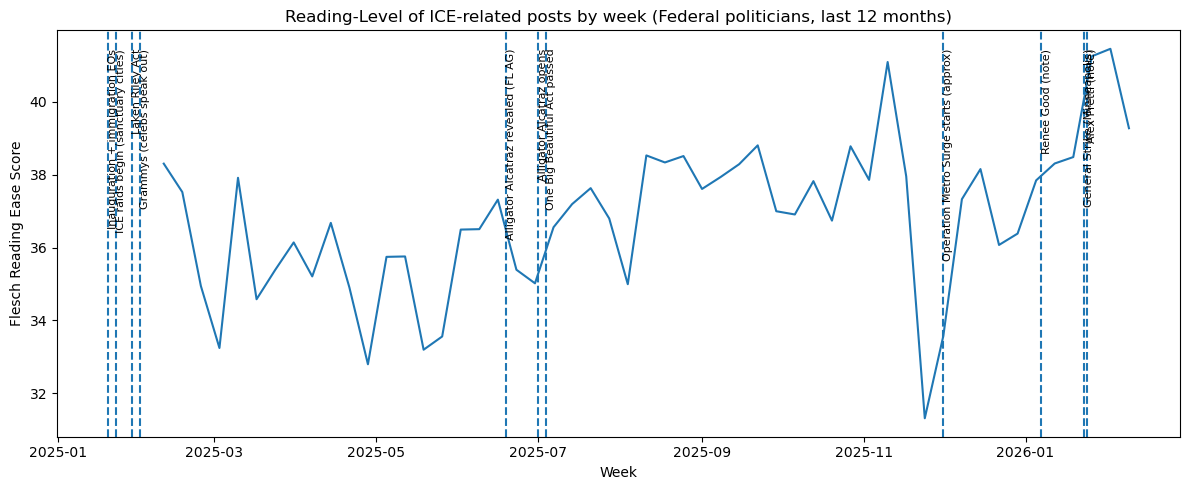

In [69]:
plt.figure(figsize=(12, 5))
plt.plot(weekly["published_at"], weekly["read_ease"])
plt.title("Reading-Level of ICE-related posts by week (Federal politicians, last 12 months)")
plt.xlabel("Week")
plt.ylabel("Flesch Reading Ease Score")
ymax = weekly["read_ease"].max()
for _, r in events_df.iterrows():
    plt.axvline(r["date"], linestyle="--")
    plt.text(r["date"], ymax, r["label"], rotation=90, va="top", fontsize=8)

plt.tight_layout()

In [77]:
max(weekly['gunning_fog'])

np.float64(15.93188056380919)

Text(2025-02-10 00:00:00+00:00, 16, 'College Senior Level')

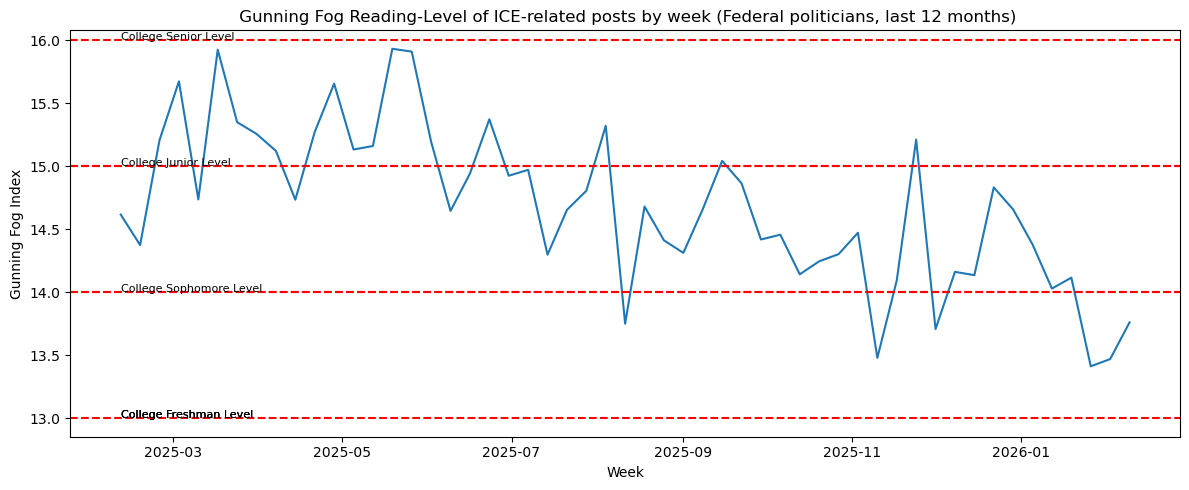

In [86]:
plt.figure(figsize=(12, 5))
plt.plot(weekly["published_at"], weekly["gunning_fog"])
plt.title(" Gunning Fog Reading-Level of ICE-related posts by week (Federal politicians, last 12 months)")
plt.xlabel("Week")
plt.ylabel("Gunning Fog Index")
ymax = weekly["gunning_fog"].max()
#for _, r in events_df.iterrows():
 #   plt.axvline(r["date"], linestyle="--")
  #  plt.text(r["date"], ymax, r["label"], rotation=90, va="top", fontsize=8)

plt.tight_layout()
plt.axhline(13, color='red', linestyle='--', label='College Freshman Level')
plt.text(weekly["published_at"].iloc[0], 13, "College Freshman Level", fontsize=8)
plt.axhline(14, color='red', linestyle='--', label='College Sophomore Level')
plt.text(weekly["published_at"].iloc[0], 13, "College Freshman Level", fontsize=8)
plt.axhline(15, color='red', linestyle='--', label='College Junior Level')
plt.text(weekly["published_at"].iloc[0], 13, "College Freshman Level", fontsize=8)
plt.axhline(14, color='red', linestyle='--', label='College Sophomore Level')
plt.text(weekly["published_at"].iloc[0], 14, "College Sophomore Level", fontsize=8)
plt.axhline(15, color='red', linestyle='--', label='College Junior Level')
plt.text(weekly["published_at"].iloc[0], 15, "College Junior Level", fontsize=8)
plt.axhline(16, color='red', linestyle='--', label='College Senior Level')
plt.text(weekly["published_at"].iloc[0], 16, "College Senior Level", fontsize=8)